In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import ElasticNetCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import TimeSeriesSplit


In [2]:
df= pd.read_excel('/content/transit_simulator_edited.xlsx')

df.head()

,Date,BART,MUNI,Ferry,Bridge,Visits,Month
0,2020-01-01,2083734,8884200,420907,5420879,4489375,1
1,2020-02-01,1953373,8429898,408246,5222944,4210672,2
2,2020-03-01,804768,6322593,158585,3848968,2060361,3
3,2020-04-01,70475,1342800,5591,2506819,565890,4
4,2020-05-01,84218,1657400,7067,3443831,772125,5


In [3]:
DF2= df[['BART', 'MUNI', 'Ferry', 'Bridge', 'Visits']]

In [4]:
df['ln_visits']= np.log(df['Visits'])
df['ln_bart']= np.log(df['BART'])
df['ln_muni']= np.log(df['MUNI'])
df['ln_ferry']= np.log(df['Ferry'])
df['ln_bridge']= np.log(df['Bridge'])

# ElasticNet Regularization


In [5]:
month_dummies= pd.get_dummies(df['Month'], drop_first=True).astype(int)
X= pd.concat([month_dummies, df[['ln_bart', 'ln_muni', 'ln_ferry', 'ln_bridge']]], axis=1)

y= df['ln_visits']

In [6]:
#exploratory
enet_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("enet", ElasticNetCV(
        l1_ratio=0.8,
        alphas=np.logspace(-3, 1, 50),
        max_iter=100000,
        random_state=42
    ))
])

X.columns = X.columns.astype(str)

enet_pipe.fit(X, y)
enet = enet_pipe.named_steps["enet"]
enet_df = pd.DataFrame({"variable": X.columns, "coef": enet.coef_}) \
             .sort_values("coef", key=abs, ascending=False)


print(f"Chosen l1_ratio={enet.l1_ratio_}, alpha={enet.alpha_}")
print(enet_df[enet_df.coef != 0])

Chosen l1_ratio=0.8, alpha=0.001
     variable      coef
11    ln_bart  0.279062
14  ln_bridge  0.067473
13   ln_ferry  0.063847
7           9 -0.014204
9          11 -0.009760
6           8 -0.009262
8          10 -0.007760
2           4 -0.005311
10         12  0.004881
5           7  0.004590
0           2  0.004199
3           5 -0.003059
4           6  0.002575
1           3 -0.001446


In [7]:
model = Lasso(alpha=0.002)
model.fit(X, y)

lasso_coef_df = pd.DataFrame({"variable": X.columns, "coef": model.coef_})
print(lasso_coef_df[lasso_coef_df.coef != 0])

     variable      coef
2           4 -0.013838
5           7  0.006756
7           9 -0.016780
9          11 -0.015513
10         12  0.003001
11    ln_bart  0.360541
13   ln_ferry  0.113159
14  ln_bridge  0.162214


# Cross Validation

In [8]:
split_idx = int(len(X) * 0.7)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

enet_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("enet", ElasticNetCV(
        l1_ratio=[.1, .5, .7, .8, .9, .95, .99, 1],
        alphas=np.logspace(-3, 1, 50),
        cv=5,
        max_iter=100000,
        random_state=42,
        n_jobs=-1
    ))
])

outer_cv_scores = cross_val_score(enet_pipe, X_train, y_train, cv=5)
print(f"Outer CV R2: {outer_cv_scores.mean():.4f} (+/- {outer_cv_scores.std():.4f})")

enet_pipe.fit(X_train, y_train)
test_r2 = enet_pipe.score(X_test, y_test)

enet = enet_pipe.named_steps["enet"]
enet_df = pd.DataFrame({"variable": X.columns, "coef": enet.coef_}) \
             .sort_values("coef", key=abs, ascending=False)

print(f"Chosen l1_ratio={enet.l1_ratio_}, alpha={enet.alpha_:.5f}")
print(enet_df[enet_df.coef != 0])

Outer CV R2: 0.7803 (+/- 0.2394)
Chosen l1_ratio=0.9, alpha=0.00176
     variable      coef
11    ln_bart  0.302489
14  ln_bridge  0.080122
13   ln_ferry  0.061446
7           9 -0.011979
9          11 -0.010081
6           8 -0.008762
8          10 -0.005772
0           2  0.005265
10         12  0.003790
5           7  0.003208
4           6  0.001140
2           4 -0.000216


# Monthly Growth Rate

In [15]:
df_diff = df[['ln_visits', 'ln_bart', 'ln_muni', 'ln_ferry', 'ln_bridge']].diff().dropna()

month_dummies = pd.get_dummies(df['Month'], drop_first=True).astype(int).iloc[1:]

X_diff = pd.concat([month_dummies, df_diff[['ln_bart', 'ln_muni', 'ln_ferry', 'ln_bridge']]], axis=1)
X_diff.columns = X_diff.columns.astype(str)
y_diff = df_diff['ln_visits']

split_idx = int(len(X_diff) * 0.7)
X_train, X_test = X_diff.iloc[:split_idx], X_diff.iloc[split_idx:]
y_train, y_test = y_diff.iloc[:split_idx], y_diff.iloc[split_idx:]

enet_pipe.fit(X_train, y_train)
outer_cv_scores = cross_val_score(enet_pipe, X_train, y_train, cv=5)
print(f"Cross Val R2: {outer_cv_scores.mean():.4f} (+/- {outer_cv_scores.std():.4f})")

print(pd.DataFrame({"Var": X_diff.columns, "Coef": enet_pipe.named_steps['enet'].coef_}).query("Coef != 0"))

Cross Val R2: 0.7517 (+/- 0.1259)
          Var      Coef
0           2  0.005436
1           3 -0.005807
2           4 -0.002657
4           6  0.006590
5           7  0.001173
6           8 -0.010771
8          10  0.005144
10         12  0.013112
11    ln_bart  0.139474
13   ln_ferry  0.016620
14  ln_bridge  0.083553


In [16]:
scaler = enet_pipe.named_steps["scaler"]
enet = enet_pipe.named_steps["enet"]

unscaled_coefs = enet.coef_ / scaler.scale_

pd.DataFrame({
    "Var": X_diff.columns,
    "Scaled_Coef": enet.coef_,
    "Unscaled_Elasticity": unscaled_coefs
}).query("Scaled_Coef != 0")

,Var,Scaled_Coef,Unscaled_Elasticity
0,2,0.005436,0.017959
1,3,-0.005807,-0.021209
2,4,-0.002657,-0.009703
4,6,0.006590,0.024069
5,7,0.001173,0.004285
6,8,-0.010771,-0.039339
8,10,0.005144,0.018787
10,12,0.013112,0.047886
11,ln_bart,0.139474,0.351841
13,ln_ferry,0.016620,0.029312


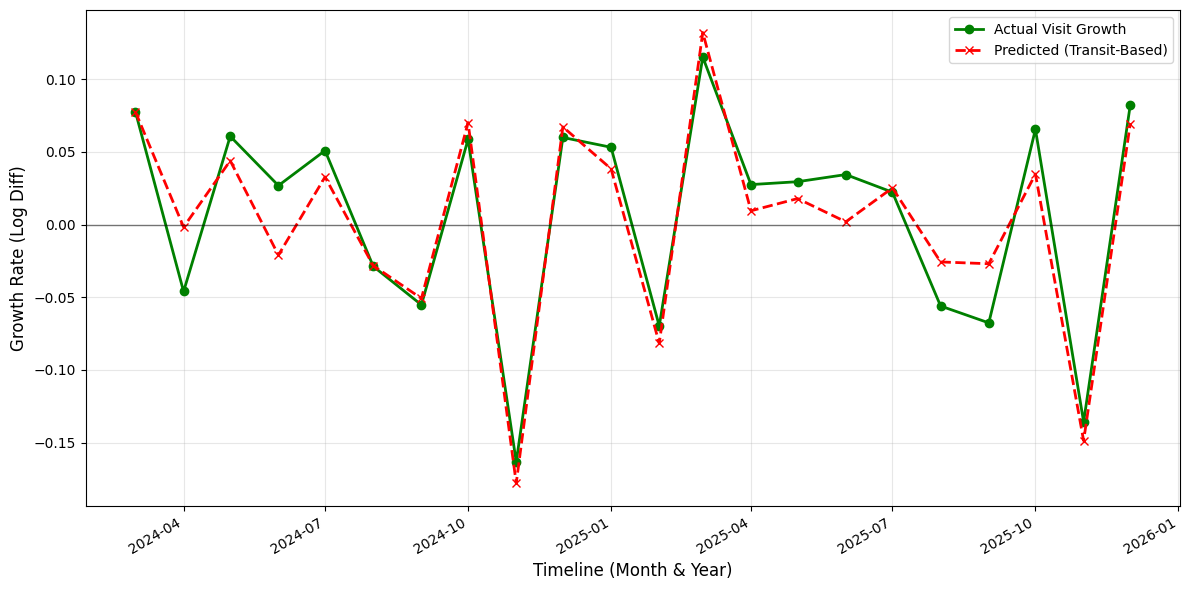

In [17]:
df = df.sort_values('Date').reset_index(drop=True)

test_dates = df.loc[X_test.index, 'Date']

plt.figure(figsize=(12, 6))

plt.plot(test_dates, y_test, label='Actual Visit Growth', color='green', marker='o', linewidth=2)
plt.plot(test_dates, enet_pipe.predict(X_test), label='Predicted (Transit-Based)', color='red', linestyle='--', marker='x', linewidth=2)

plt.axhline(0, color='black', lw=1, ls='-', alpha=0.5)

plt.xlabel("Timeline (Month & Year)", fontsize=12)
plt.ylabel("Growth Rate (Log Diff)", fontsize=12)

plt.gcf().autofmt_xdate()

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Unscaled Elasticities

In [33]:
df_diff = df[['ln_visits','ln_bart','ln_muni','ln_ferry','ln_bridge']].diff().dropna()
month_dummies = pd.get_dummies(df['Month'], drop_first=True).astype(int).iloc[1:]

X_diff = pd.concat([month_dummies, df_diff[['ln_bart','ln_muni','ln_ferry','ln_bridge']]], axis=1)
X_diff.columns = X_diff.columns.astype(str)
y_diff = df_diff['ln_visits']

split_idx = int(len(X_diff) * 0.7)
X_train, X_test = X_diff.iloc[:split_idx], X_diff.iloc[split_idx:]
y_train, y_test = y_diff.iloc[:split_idx], y_diff.iloc[split_idx:]

print(f"Train: {df.loc[X_train.index,'Date'].min().date()} to {df.loc[X_train.index,'Date'].max().date()}")
print(f"Test:  {df.loc[X_test.index,'Date'].min().date()} to {df.loc[X_test.index,'Date'].max().date()}")

diff_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("enet", ElasticNetCV(
        l1_ratio=[.1, .5, .7, .8, .9, .95, .99, 1],
        alphas=np.logspace(-2, 2, 100),
        cv=5,
        max_iter=100000,
        random_state=42,
        n_jobs=-1
    ))
])

diff_pipe.fit(X_train, y_train)

cv_scores = cross_val_score(diff_pipe, X_train, y_train, cv=5)
print(f"\nCV R2:   {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print(f"Test R2: {diff_pipe.score(X_test, y_test):.4f}")

print("\nMarginal effects (10% shock):")
for var, label in [('ln_bart','BART'), ('ln_ferry','Ferry'), ('ln_bridge','Bridge')]:
    example = X_test.mean().to_frame().T
    base_pred = diff_pipe.predict(example)[0]
    example_shock = example.copy()
    example_shock[var] += np.log(1.10)
    shocked_pred = diff_pipe.predict(example_shock)[0]
    print(f"  {label}: {(shocked_pred - base_pred)*100:.2f} pp")


Train: 2020-02-01 to 2024-02-01
Test:  2024-03-01 to 2025-12-01

CV R2:   0.7503 (+/- 0.1349)
Test R2: 0.9139

Marginal effects (10% shock):
  BART: 3.02 pp
  Ferry: 0.53 pp
  Bridge: 7.91 pp


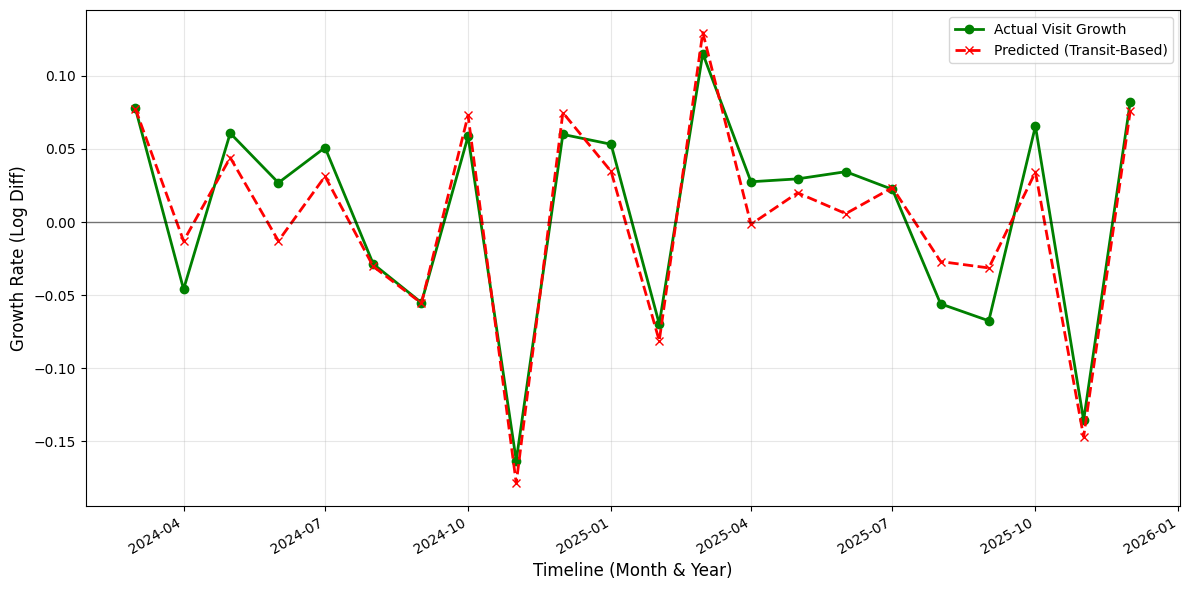

In [32]:
test_dates = df.loc[X_test.index, 'Date']

plt.figure(figsize=(12, 6))
plt.plot(test_dates, y_test, label='Actual Visit Growth', color='green', marker='o', linewidth=2)
plt.plot(test_dates, diff_pipe.predict(X_test), label='Predicted (Transit-Based)', color='red', linestyle='--', marker='x', linewidth=2)
plt.axhline(0, color='black', lw=1, ls='-', alpha=0.5)
plt.xlabel("Timeline (Month & Year)", fontsize=12)
plt.ylabel("Growth Rate (Log Diff)", fontsize=12)
plt.gcf().autofmt_xdate()
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()